# CNN Architecture Comparison — VGG16 & GoogLeNet vs. ResNet18 Baseline

**Objective:** Train and evaluate two additional pretrained CNN architectures (VGG16, GoogLeNet /
Inception v1) under the **exact same experimental protocol** used in `02_ResNet18_Training.ipynb`
(dataset, subject-level split, augmentation, preprocessing, batch size, optimizer, learning rate,
epochs), then benchmark all three architectures head-to-head to select the backbone that will be
carried forward into the MRI feature-extraction / multimodal-fusion notebook.

**ResNet18 is not retrained here.** Its final test-set performance is reproduced by loading the
checkpoint saved in `02_ResNet18_Training.ipynb` (`best_resnet18.pth`) and running inference only,
so it can be scored on the identical extended metric set used for VGG16 and GoogLeNet.

| Section | Content |
|---------|---------|
| 1 | Environment setup & imports |
| 2 | Dataset reconstruction (identical to Notebook 02) |
| 3 | Subject-level train / validation / test split (identical) |
| 4 | Preprocessing & augmentation (identical) |
| 5 | Shared training / evaluation utilities |
| 6 | VGG16 — training & evaluation |
| 7 | GoogLeNet (Inception v1) — training & evaluation |
| 8 | ResNet18 baseline — inference-only recap |
| 9 | Final comparison table & bar charts |
| 10 | Discussion & model selection |

**Reused protocol (must match Notebook 02 exactly):**
- Dataset: OASIS Alzheimer's MRI (Kaggle `ninadaithal/imagesoasis`), 3-class merged labelling
  (`Dementia` = Mild + Moderate, `Non Demented`, `Very mild Dementia`)
- Split: subject-level, 70 / 15 / 15 (train / val / test), `random_state=42`
- Augmentation: horizontal flip, ±10° rotation, ±5% translate/scale (train only)
- Preprocessing: resize 224×224, ImageNet normalisation
- Batch size: 32, `WeightedRandomSampler` on the training set
- Optimizer: Adam, `lr=1e-4`, `ReduceLROnPlateau` (mode=`max`, factor=0.5, patience=2) on val Macro-F1
- Loss: class-weighted `CrossEntropyLoss`
- Epochs: 10


---
## Cell 1 — Environment Setup & Imports

In [1]:
import os
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/alzheimer_project"
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project dir:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/alzheimer_project


In [2]:
!pip install -q kaggle

In [3]:
pip install sympy==1.13.3

In [4]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
)

In [5]:
# Identical seeding / device setup to Notebook 02
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


---
## Cell 2 — Dataset Reconstruction (Identical to Notebook 02)

The raw OASIS archive is re-downloaded only if it is not already present under `MRI_DATA/Data`.
The inventory, subject-ID extraction, and 3-class label merge are copied verbatim from
`02_ResNet18_Training.ipynb` so that every downstream model sees the same population of images.

In [6]:
import os

if not os.path.isdir("MRI_DATA/Data"):
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_283606f7db27511d5bedbdc1c43c0695"
    !kaggle datasets download -d ninadaithal/imagesoasis
    !unzip -q imagesoasis.zip -d MRI_DATA
else:
    print("MRI_DATA/Data already present — skipping download.")

DATA_DIR = "MRI_DATA/Data" if os.path.isdir("MRI_DATA/Data") else "/content/MRI_DATA/Data"
print("Data dir:", DATA_DIR)

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:14<00:00, 88.5MB/s]

Data dir: MRI_DATA/Data


In [7]:
# Label-merge map: collapse Mild + Moderate -> "Dementia" (identical to Notebook 02)
LABEL_MERGE = {
    "Mild Dementia":      "Dementia",
    "Moderate Dementia":  "Dementia",
    "Very mild Dementia": "Very mild Dementia",
    "Non Demented":       "Non Demented",
}

CLASS_NAMES = [
    "Dementia",           # merged: Mild + Moderate Dementia
    "Non Demented",
    "Very mild Dementia",
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

print("Class mapping:", CLASS_TO_IDX)

Class mapping: {'Dementia': 0, 'Non Demented': 1, 'Very mild Dementia': 2}


In [8]:
all_records = []
subject_pattern = re.compile(r"(OAS\d+_\d+)", re.IGNORECASE)

for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    merged_label = LABEL_MERGE.get(class_name, class_name)

    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        match = subject_pattern.search(fname)
        subject_id = match.group(1) if match else fname

        all_records.append({
            "subject_id": subject_id,
            "image_path": fpath,
            "label": merged_label
        })

inventory_df = pd.DataFrame(all_records)
print("Total images:", len(inventory_df))
print("Unique subjects:", inventory_df["subject_id"].nunique())
inventory_df["label"].value_counts()

Total images: 86437
Unique subjects: 347


,count
label,
Non Demented,67222
Very mild Dementia,13725
Dementia,5490


---
## Cell 3 — Subject-Level Train / Validation / Test Split (Identical)

Splitting is performed at the **subject** level (one split decision per patient, not per image) to
prevent scans from the same individual leaking across train/val/test — the exact procedure used
for ResNet18: 70% train, then a 50/50 split of the remaining 30% into validation and test
(15% / 15% overall), `random_state=42`.

In [9]:
subject_df = (
    inventory_df
    .groupby("subject_id")
    .first()
    .reset_index()
)

train_subjects, temp_subjects = train_test_split(
    subject_df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

train_ids = set(train_subjects["subject_id"])
val_ids   = set(val_subjects["subject_id"])
test_ids  = set(test_subjects["subject_id"])

train_df = inventory_df[inventory_df["subject_id"].isin(train_ids)]
val_df   = inventory_df[inventory_df["subject_id"].isin(val_ids)]
test_df  = inventory_df[inventory_df["subject_id"].isin(test_ids)]

print("Train images:", len(train_df), "| Train subjects:", len(train_ids))
print("Val images:  ", len(val_df),   "| Val subjects:  ", len(val_ids))
print("Test images: ", len(test_df),  "| Test subjects: ", len(test_ids))

Train images: 59414 | Train subjects: 242
Val images:   12627 | Val subjects:   52
Test images:  14396 | Test subjects:  53


---
## Cell 4 — Preprocessing & Augmentation (Identical)

MRI-appropriate augmentation, unchanged from Notebook 02:
- Horizontal flip — anatomically plausible for brain MRI slices
- Small rotation (≤10°) — accounts for head-tilt variation
- Small translate (5%) + scale (±5%) — simulates positioning differences
- No vertical flip / colour jitter / strong distortions (unrealistic for MRI)

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
class MRIDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        label = self.class_to_idx[row["label"]]
        return image, label


train_dataset = MRIDataset(train_df, train_transform)
val_dataset   = MRIDataset(val_df,   test_transform)
test_dataset  = MRIDataset(test_df,  test_transform)

assert train_dataset.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx == CLASS_TO_IDX
print("Class mapping consistent across splits:", CLASS_TO_IDX)

Class mapping consistent across splits: {'Dementia': 0, 'Non Demented': 1, 'Very mild Dementia': 2}


In [12]:
# Per-sample weighting for class-imbalance mitigation (identical to Notebook 02)
class_counts = train_df["label"].value_counts()
weights_per_class = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = train_df["label"].map(weights_per_class).values

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)

---
## Cell 5 — Shared Training / Evaluation Utilities

A single training routine and a single full-metric evaluation routine are defined once and reused
for VGG16, GoogLeNet, **and** the ResNet18 inference-only recap, guaranteeing that every
architecture is measured on identical code. The optimizer (Adam, `lr=1e-4`), scheduler
(`ReduceLROnPlateau` on val Macro-F1), loss (class-weighted cross-entropy) and epoch budget (10)
all match Notebook 02.

In [13]:
EPOCHS = 10

# Class weights on merged training labels (identical to Notebook 02)
labels_train = train_df["label"]
classes_arr  = np.array(CLASS_NAMES)

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=classes_arr,
    y=labels_train
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASS_NAMES, class_weights_np)))

Class weights: {'Dementia': np.float64(4.845771144278607), 'Non Demented': np.float64(0.4381466486729645), 'Very mild Dementia': np.float64(1.9558232931726907)}


In [14]:
def evaluate_loss_acc(model, loader, criterion):
    """Quick eval used during training for the LR scheduler / progress logging."""
    model.eval()
    loss_sum = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item()

            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return loss_sum / len(loader), acc, macro_f1


def train_model(model, model_name, checkpoint_path, epochs=EPOCHS):
    """Generic training loop — identical optimizer / scheduler / loss / epoch protocol
    used for ResNet18 in Notebook 02."""
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
    best_val_f1 = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_loss, val_acc, val_f1 = evaluate_loss_acc(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        scheduler.step(val_f1)

        marker = ""
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), checkpoint_path)
            marker = f"  -> best model saved (Macro-F1={val_f1:.4f})"

        print(
            f"[{model_name}] Epoch {epoch+1}/{epochs} | "
            f"Train Loss={train_loss:.4f} Acc={train_acc:.4f} | "
            f"Val Loss={val_loss:.4f} Acc={val_acc:.4f} Macro-F1={val_f1:.4f}{marker}"
        )

    return history

In [15]:
def evaluate_full(model, loader):
    """Inference-only pass returning y_true, y_pred and class probabilities
    (needed for ROC-AUC and Log Loss)."""
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1)

            all_probs.append(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_proba = np.vstack(all_probs)
    return y_true, y_pred, y_proba


def compute_full_metrics(y_true, y_pred, y_proba):
    """Full metric suite used for every architecture in this comparison."""
    return {
        "Accuracy":          accuracy_score(y_true, y_pred),
        "Precision (Macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (Macro)":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (Macro)":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (Weighted)":     f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC (OvR)":     roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
        "MCC":               matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa":     cohen_kappa_score(y_true, y_pred),
        "Log Loss":          log_loss(y_true, y_proba, labels=list(range(len(CLASS_NAMES)))),
    }


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(xticks_rotation=45)
    plt.title(f"{model_name} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_proba, model_name):
    plt.figure(figsize=(6, 5))
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc_val:.3f})")

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} — ROC Curve (One-vs-Rest)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_training_curves(history, model_name):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_name} — Training Loss Curve")
    axes[0].legend()

    axes[1].plot(epochs_range, history["val_acc"], label="Val Accuracy", color="tab:green")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{model_name} — Validation Accuracy Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


results = {}   # populated with full_metrics for ResNet18 / VGG16 / GoogLeNet
histories = {} # populated with training history for VGG16 / GoogLeNet

---
## Cell 6 — VGG16 (Training & Evaluation)

`torchvision`'s ImageNet-pretrained VGG16 with the final classifier layer replaced for 3-class
output. Trained with the identical optimizer, scheduler, loss and epoch budget as ResNet18.

In [ ]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, len(CLASS_NAMES))
vgg16 = vgg16.to(DEVICE)

VGG16_CKPT = f"{PROJECT_DIR}/best_vgg16.pth"
histories["VGG16"] = train_model(vgg16, "VGG16", VGG16_CKPT)

[VGG16] Epoch 1/10 | Train Loss=0.2673 Acc=0.7812 | Val Loss=2.0032 Acc=0.5700 Macro-F1=0.3889  -> best model saved (Macro-F1=0.3889)
[VGG16] Epoch 2/10 | Train Loss=0.0850 Acc=0.9035 | Val Loss=1.1934 Acc=0.6799 Macro-F1=0.3856
[VGG16] Epoch 3/10 | Train Loss=0.0560 Acc=0.9392 | Val Loss=1.2915 Acc=0.6761 Macro-F1=0.4193  -> best model saved (Macro-F1=0.4193)
[VGG16] Epoch 4/10 | Train Loss=0.0435 Acc=0.9518 | Val Loss=1.3068 Acc=0.8034 Macro-F1=0.4370  -> best model saved (Macro-F1=0.4370)
[VGG16] Epoch 5/10 | Train Loss=0.0380 Acc=0.9613 | Val Loss=1.5591 Acc=0.7235 Macro-F1=0.4286
[VGG16] Epoch 6/10 | Train Loss=0.0253 Acc=0.9737 | Val Loss=1.5081 Acc=0.7698 Macro-F1=0.4654  -> best model saved (Macro-F1=0.4654)
[VGG16] Epoch 7/10 | Train Loss=0.0301 Acc=0.9711 | Val Loss=1.7891 Acc=0.7242 Macro-F1=0.4180


In [19]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

vgg16.classifier[6] = nn.Linear(
    vgg16.classifier[6].in_features,
    len(CLASS_NAMES)
)

vgg16 = vgg16.to(DEVICE)

VGG16_CKPT = "/content/drive/MyDrive/best_vgg16.pth"
vgg16.load_state_dict(
    torch.load(VGG16_CKPT, map_location=DEVICE)
)

vgg16.eval()

print("✅ Loaded saved VGG16 checkpoint.")

✅ Loaded saved VGG16 checkpoint.


In [20]:
# Load best checkpoint and run test-set inference
vgg16.load_state_dict(torch.load(VGG16_CKPT, map_location=DEVICE))
vgg16.eval()

y_true_vgg, y_pred_vgg, y_proba_vgg = evaluate_full(vgg16, test_loader)

print(classification_report(y_true_vgg, y_pred_vgg, target_names=CLASS_NAMES))

results["VGG16"] = compute_full_metrics(y_true_vgg, y_pred_vgg, y_proba_vgg)
results["VGG16"]

                    precision    recall  f1-score   support

          Dementia       0.20      0.44      0.27       671
      Non Demented       0.91      0.91      0.91     11346
Very mild Dementia       0.70      0.46      0.55      2379

          accuracy                           0.81     14396
         macro avg       0.60      0.60      0.58     14396
      weighted avg       0.84      0.81      0.82     14396



{'Accuracy': 0.8135593220338984,
 'Precision (Macro)': 0.6007731763630693,
 'Recall (Macro)': 0.6004915526332766,
 'F1 (Macro)': 0.5771382753242543,
 'F1 (Weighted)': 0.8215139628362862,
 'Balanced Accuracy': np.float64(0.6004915526332766),
 'ROC-AUC (OvR)': np.float64(0.8654924737302703),
 'MCC': np.float64(0.48075181841847403),
 "Cohen's Kappa": np.float64(0.4763377105234441),
 'Log Loss': 1.1117261933942224}

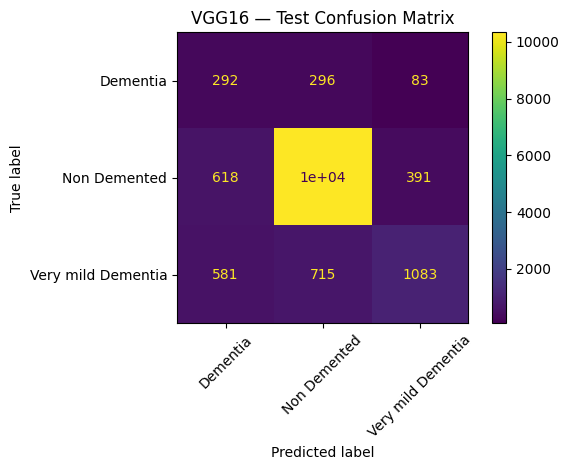

In [21]:
plot_confusion_matrix(y_true_vgg, y_pred_vgg, "VGG16")

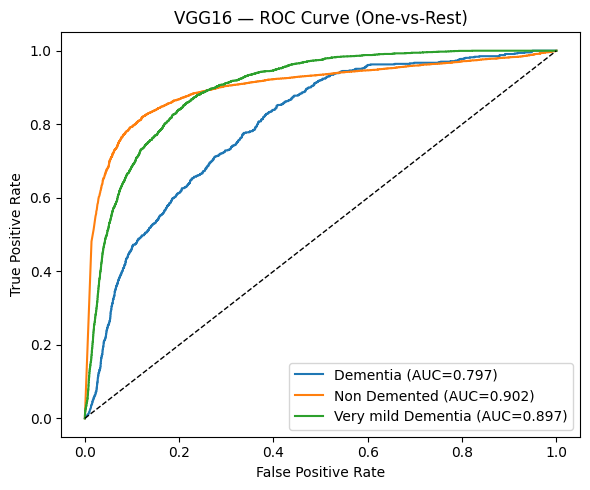

In [22]:
plot_roc_curve(y_true_vgg, y_proba_vgg, "VGG16")

### 📝 Observation — VGG16

```
Test Accuracy          : ___
Macro F1               : ___
Best/weakest class     : ___
Convergence behaviour  : ___   (e.g. epoch of best val Macro-F1, over/under-fitting signs)
```


---
## Cell 7 — GoogLeNet / Inception v1 (Training & Evaluation)

`torchvision`'s ImageNet-pretrained GoogLeNet. The auxiliary classifier heads (used only to help
gradient flow during the original Inception training) are disabled so the model exposes a single
output, keeping the training loop identical to ResNet18 and VGG16. `transform_input` is disabled
since normalisation is already handled by our own `transforms.Normalize` step.

In [25]:
googlenet = models.googlenet(
    weights=models.GoogLeNet_Weights.DEFAULT,
    aux_logits=True,       # required to load ImageNet-pretrained weights
    transform_input=False  # we already apply ImageNet normalisation ourselves
)

# Disable auxiliary heads post-load so forward() returns a single tensor,
# keeping the training loop identical across all three architectures
googlenet.aux_logits = False
googlenet.aux1 = None
googlenet.aux2 = None

googlenet.fc = nn.Linear(googlenet.fc.in_features, len(CLASS_NAMES))
googlenet = googlenet.to(DEVICE)

GOOGLENET_CKPT = f"{PROJECT_DIR}/best_googlenet.pth"
histories["GoogLeNet"] = train_model(googlenet, "GoogLeNet", GOOGLENET_CKPT)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 163MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


[GoogLeNet] Epoch 1/10 | Train Loss=0.1728 Acc=0.8486 | Val Loss=0.9843 Acc=0.6998 Macro-F1=0.4839  -> best model saved (Macro-F1=0.4839)
[GoogLeNet] Epoch 2/10 | Train Loss=0.0490 Acc=0.9487 | Val Loss=0.9645 Acc=0.7455 Macro-F1=0.4565
[GoogLeNet] Epoch 3/10 | Train Loss=0.0288 Acc=0.9718 | Val Loss=0.9826 Acc=0.8033 Macro-F1=0.4736
[GoogLeNet] Epoch 4/10 | Train Loss=0.0213 Acc=0.9806 | Val Loss=0.9475 Acc=0.7941 Macro-F1=0.4821
[GoogLeNet] Epoch 5/10 | Train Loss=0.0062 Acc=0.9942 | Val Loss=1.0770 Acc=0.7823 Macro-F1=0.4669
[GoogLeNet] Epoch 6/10 | Train Loss=0.0066 Acc=0.9940 | Val Loss=1.1045 Acc=0.7784 Macro-F1=0.4921  -> best model saved (Macro-F1=0.4921)
[GoogLeNet] Epoch 7/10 | Train Loss=0.0065 Acc=0.9946 | Val Loss=1.2433 Acc=0.7739 Macro-F1=0.4882
[GoogLeNet] Epoch 8/10 | Train Loss=0.0046 Acc=0.9961 | Val Loss=1.1957 Acc=0.8251 Macro-F1=0.4893
[GoogLeNet] Epoch 9/10 | Train Loss=0.0053 Acc=0.9960 | Val Loss=1.0577 Acc=0.8300 Macro-F1=0.4853
[GoogLeNet] Epoch 10/10 | Train

In [26]:
googlenet.load_state_dict(torch.load(GOOGLENET_CKPT, map_location=DEVICE))
googlenet.eval()

y_true_gnet, y_pred_gnet, y_proba_gnet = evaluate_full(googlenet, test_loader)

print(classification_report(y_true_gnet, y_pred_gnet, target_names=CLASS_NAMES))

results["GoogLeNet"] = compute_full_metrics(y_true_gnet, y_pred_gnet, y_proba_gnet)
results["GoogLeNet"]

                    precision    recall  f1-score   support

          Dementia       0.35      0.34      0.35       671
      Non Demented       0.91      0.92      0.91     11346
Very mild Dementia       0.65      0.64      0.64      2379

          accuracy                           0.84     14396
         macro avg       0.64      0.63      0.63     14396
      weighted avg       0.84      0.84      0.84     14396



{'Accuracy': 0.8448180050013893,
 'Precision (Macro)': 0.6397523310352904,
 'Recall (Macro)': 0.6302591879006475,
 'F1 (Macro)': 0.6348766093106591,
 'F1 (Weighted)': 0.8435073681951917,
 'Balanced Accuracy': np.float64(0.6302591879006475),
 'ROC-AUC (OvR)': np.float64(0.9231514226150163),
 'MCC': np.float64(0.5498770726320815),
 "Cohen's Kappa": np.float64(0.5497629360405536),
 'Log Loss': 0.7333064260362933}

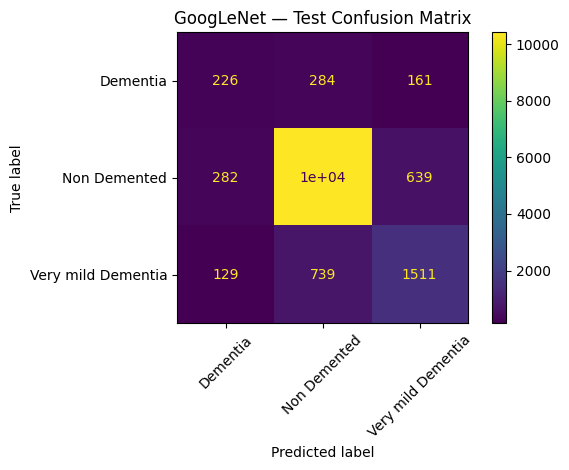

In [27]:
plot_confusion_matrix(y_true_gnet, y_pred_gnet, "GoogLeNet")

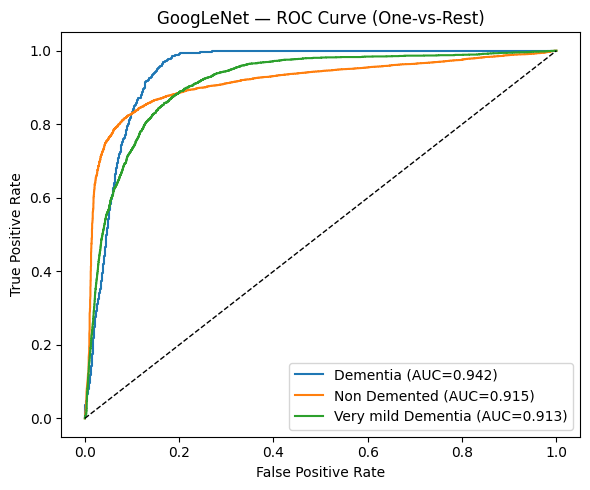

In [28]:
plot_roc_curve(y_true_gnet, y_proba_gnet, "GoogLeNet")

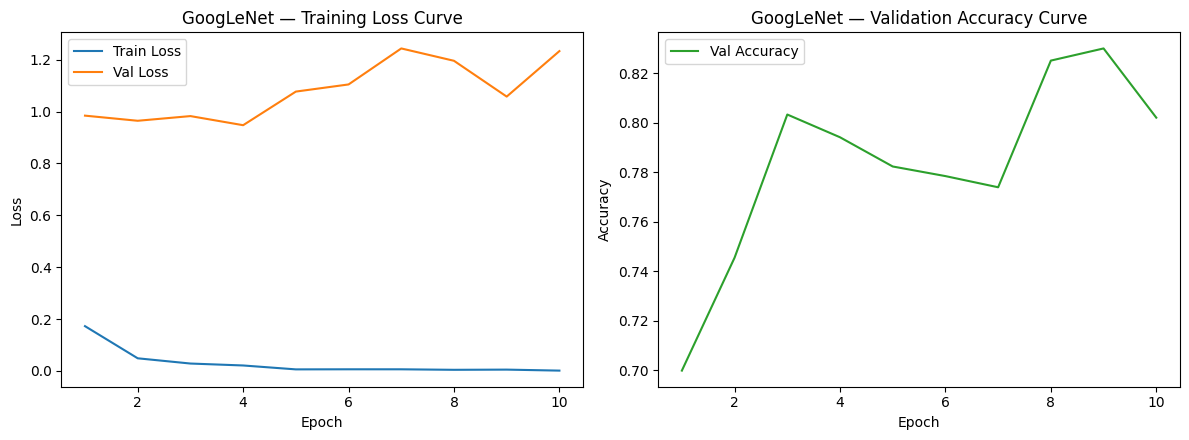

In [29]:
plot_training_curves(histories["GoogLeNet"], "GoogLeNet")

### 📝 Observation — GoogLeNet

```
Test Accuracy          : ___
Macro F1               : ___
Best/weakest class     : ___
Convergence behaviour  : ___
```


---
## Cell 8 — ResNet18 Baseline (Inference-Only Recap — No Retraining)

ResNet18 is **not** retrained. The checkpoint saved by `02_ResNet18_Training.ipynb`
(`best_resnet18.pth`) is loaded and scored once on the same `test_loader` built above, purely to
compute the extended metric set (ROC-AUC, MCC, Cohen's Kappa, Log Loss) on the same footing as
VGG16 and GoogLeNet. This is a forward pass only — no gradients, no optimizer, no training loop.

For reference, Notebook 02's originally reported test results were:

```
Accuracy      : 0.86
Macro F1      : 0.6786
Macro Precision (Dementia/Non Demented/Very mild Dementia avg) : 0.68
Macro Recall  : 0.70
Weighted F1   : 0.86
```


In [32]:
resnet18 = models.resnet18(weights=None)
resnet18.fc = nn.Linear(resnet18.fc.in_features, len(CLASS_NAMES))

RESNET18_CKPT = '/content/drive/MyDrive/alzheimer_project/best_resnet18.pth'
resnet18.load_state_dict(torch.load(RESNET18_CKPT, map_location=DEVICE))
resnet18 = resnet18.to(DEVICE)
resnet18.eval()

print("Loaded ResNet18 checkpoint from Notebook 02 — inference only, no training performed.")

y_true_res, y_pred_res, y_proba_res = evaluate_full(resnet18, test_loader)

print(classification_report(y_true_res, y_pred_res, target_names=CLASS_NAMES))

results["ResNet18"] = compute_full_metrics(y_true_res, y_pred_res, y_proba_res)
results["ResNet18"]

Loaded ResNet18 checkpoint from Notebook 02 — inference only, no training performed.
                    precision    recall  f1-score   support

          Dementia       0.37      0.57      0.45       671
      Non Demented       0.92      0.93      0.93     11346
Very mild Dementia       0.73      0.60      0.66      2379

          accuracy                           0.86     14396
         macro avg       0.68      0.70      0.68     14396
      weighted avg       0.87      0.86      0.86     14396



{'Accuracy': 0.8573214781883857,
 'Precision (Macro)': 0.675073435529017,
 'Recall (Macro)': 0.7006716475251643,
 'F1 (Macro)': 0.6786233928276122,
 'F1 (Weighted)': 0.859385050364657,
 'Balanced Accuracy': np.float64(0.7006716475251643),
 'ROC-AUC (OvR)': np.float64(0.939532078901602),
 'MCC': np.float64(0.5933962540351675),
 "Cohen's Kappa": np.float64(0.5921136222693995),
 'Log Loss': 0.46357774148058106}

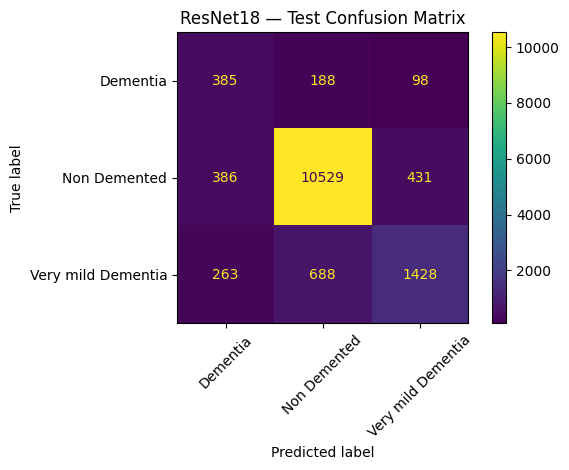

In [33]:
plot_confusion_matrix(y_true_res, y_pred_res, "ResNet18")

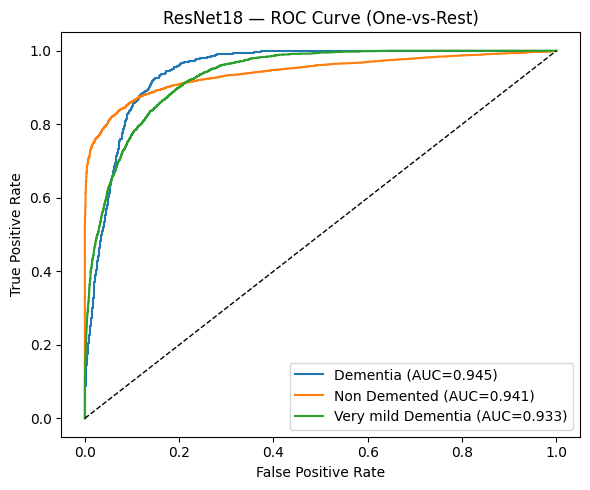

In [34]:
plot_roc_curve(y_true_res, y_proba_res, "ResNet18")

---
## Cell 9 — Final Comparison: ResNet18 vs. VGG16 vs. GoogLeNet

All three architectures were trained (or, for ResNet18, evaluated) on identical data, splits,
preprocessing and optimisation settings, so differences below are attributable to architecture
alone.

In [35]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.loc[["ResNet18", "VGG16", "GoogLeNet"]]

comparison_cols = [
    "Accuracy", "F1 (Macro)", "Balanced Accuracy", "ROC-AUC (OvR)", "MCC", "Log Loss"
]
comparison_df[comparison_cols].round(4)

,Accuracy,F1 (Macro),Balanced Accuracy,ROC-AUC (OvR),MCC,Log Loss
ResNet18,0.8573,0.6786,0.7007,0.9395,0.5934,0.4636
VGG16,0.8136,0.5771,0.6005,0.8655,0.4808,1.1117
GoogLeNet,0.8448,0.6349,0.6303,0.9232,0.5499,0.7333


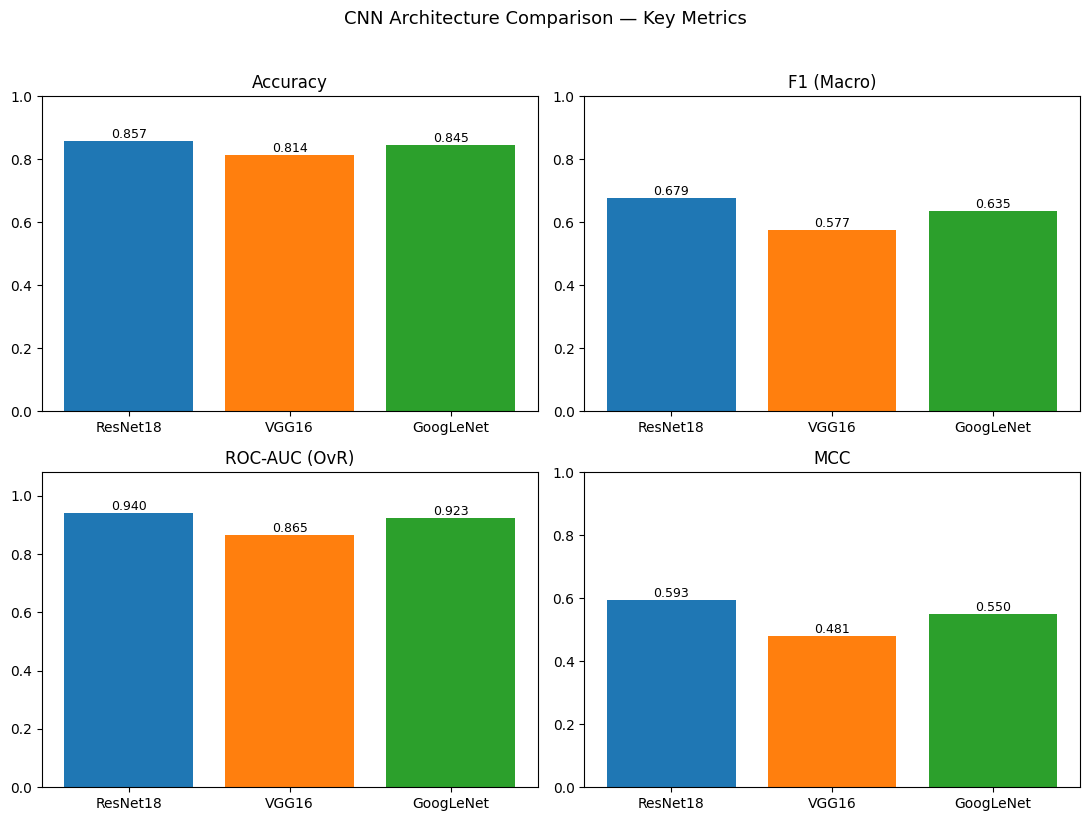

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

plot_specs = [
    ("Accuracy", axes[0, 0]),
    ("F1 (Macro)", axes[0, 1]),
    ("ROC-AUC (OvR)", axes[1, 0]),
    ("MCC", axes[1, 1]),
]

colors = ["tab:blue", "tab:orange", "tab:green"]
model_order = ["ResNet18", "VGG16", "GoogLeNet"]

for metric_name, ax in plot_specs:
    values = [results[m][metric_name] for m in model_order]
    bars = ax.bar(model_order, values, color=colors)
    ax.set_title(metric_name)
    ax.set_ylim(0, max(1.0, max(values) * 1.15))
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("CNN Architecture Comparison — Key Metrics", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 📝 Observation — Cross-Architecture Comparison

| Metric | ResNet18 | VGG16 | GoogLeNet | Best |
|--------|----------|-------|-----------|------|
| Accuracy | ___ | ___ | ___ | ___ |
| Macro F1 | ___ | ___ | ___ | ___ |
| Balanced Accuracy | ___ | ___ | ___ | ___ |
| ROC-AUC (OvR) | ___ | ___ | ___ | ___ |
| MCC | ___ | ___ | ___ | ___ |
| Log Loss | ___ | ___ | ___ | ___ |


---
## Cell 10 — Discussion & Model Selection

**Fill in after running all cells above:**

- **Best-performing architecture:** ___ — highest Macro F1 / Balanced Accuracy / ROC-AUC combined
  with the lowest Log Loss and highest MCC (the two metrics least distorted by the strong class
  imbalance towards `Non Demented`).
- **Trade-offs observed:** ___ (e.g. parameter count / training time vs. accuracy gain; whether
  the deeper GoogLeNet or wider VGG16 over/under-fits relative to ResNet18's residual connections).
- **Minority-class behaviour (`Dementia`, the rarest merged class):** ___ — compare per-class
  recall from each classification report above, since aggregate accuracy is dominated by the
  majority `Non Demented` class.
- **Decision:** The architecture identified above will be used as the fixed backbone for MRI
  feature extraction in the next notebook, where its penultimate-layer embeddings will be combined
  with non-imaging (multimodal) features for the fusion model.

**Next notebook:** `04_Feature_Extraction_and_Fusion.ipynb` — extract embeddings from the selected
CNN's penultimate layer and combine with tabular/clinical features for multimodal classification.
